# TF-IDF 파라미터 테스트 (단일 카테고리 × 단일 윈도우)

1. **프리셋 비교**: 마케팅/NLP 관점에서 선정한 필터 구성을 한 화면에서 비교합니다.
2. **단일 설정**: 설정 셀 값으로 1회 실행(원본 vs 필터)합니다.

In [19]:
# %pip install scikit-learn pandas matplotlib wordcloud

from __future__ import annotations

import sys
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import wordcloud_lab as wl

## 설정 (여기만 수정)

In [20]:
RUNS_DIR = PROJECT_ROOT / "runs"
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "output" / "product_name_single_window_tfidf_param_test"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR: Path | None = None

# --- 대상 (카테고리 1개, 윈도우 1개) ---
TARGET_CATEGORY_CODE = "001000"  # 상의
TARGET_CATEGORY_LABEL = "상의"
TARGET_WINDOW_ID = "1w"  # 1m | 1w | 1d | rt
WINDOW_LABEL_KR = {"1m": "월간", "1w": "주간", "1d": "일간", "rt": "실시간"}

# --- TF-IDF (상품 1개 = 문서 1개, 해당 카테고리·윈도우 내부만) ---
TOP_K = 40
NGRAM_RANGE = (1, 2)
MIN_DF_RATIO = 0.005
MAX_DF_RATIO = 0.35
USE_SUBLINEAR_TF = True

# --- 점검용 ---
GENERIC_CHECK = ("티", "가방", "티셔츠", "반팔", "팬츠", "신발", "백", "맨투맨")
HIGH_DF_THRESHOLD = 0.20
SAVE_CSV = True

In [21]:
run_dir = wl.resolve_run_dir(RUNS_DIR, RUN_DIR)
items = wl.load_items(run_dir)
font_path, _ = wl.init_fonts()
if font_path:
    print(f"font: {font_path}")
print(f"run: {run_dir.name}")
print(f"대상: {TARGET_CATEGORY_LABEL} ({TARGET_CATEGORY_CODE}) / {WINDOW_LABEL_KR.get(TARGET_WINDOW_ID, TARGET_WINDOW_ID)} ({TARGET_WINDOW_ID})")

font: /System/Library/Fonts/Supplemental/AppleGothic.ttf
run: 20260527_172433
대상: 상의 (001000) / 주간 (1w)


In [22]:
def build_scope_product_docs(items: list[dict]) -> pd.DataFrame:
    ubiquitous = wl.ubiquitous_for_items(items)
    rows: list[dict] = []
    for it in wl.product_items(items):
        code, label = wl.category_key(it)
        if code != TARGET_CATEGORY_CODE and label != TARGET_CATEGORY_LABEL:
            continue
        wid, wlabel = wl.window_key(it)
        if wid != TARGET_WINDOW_ID:
            continue
        name = wl.product_display_name(it)
        if not name:
            continue
        stop = wl.generic_stopwords_for(code, label, ubiquitous)
        toks = [t for t in wl.tokenize_product_name(name) if t not in stop]
        if not toks:
            continue
        rows.append({"tokens": toks, "doc": " ".join(toks)})
    return pd.DataFrame(rows)


def count_term_in_tokens(term: str, tokens: list[str]) -> int:
    parts = term.split()
    n = len(parts)
    if n == 1:
        return tokens.count(term)
    return sum(1 for i in range(len(tokens) - n + 1) if tokens[i : i + n] == parts)


def count_term_in_docs(term: str, docs_tokens: list[list[str]]) -> int:
    return sum(count_term_in_tokens(term, toks) for toks in docs_tokens)


def run_tfidf_scope(
    scope_docs_df: pd.DataFrame,
    *,
    top_k: int,
    ngram_range: tuple[int, int],
    min_df_ratio: float,
    max_df_ratio: float,
    use_sublinear_tf: bool,
) -> pd.DataFrame:
    n_docs = len(scope_docs_df)
    min_df = max(1, int(np.ceil(n_docs * min_df_ratio)))
    vectorizer = TfidfVectorizer(
        tokenizer=str.split,
        preprocessor=None,
        token_pattern=None,
        lowercase=False,
        ngram_range=ngram_range,
        min_df=min_df,
        max_df=max_df_ratio,
        sublinear_tf=use_sublinear_tf,
    )
    X = vectorizer.fit_transform(scope_docs_df["doc"].tolist())
    terms = np.array(vectorizer.get_feature_names_out())
    tfidf_sum = np.asarray(X.sum(axis=0)).ravel()
    df_ratio = np.asarray((X > 0).sum(axis=0)).ravel() / n_docs
    order = np.argsort(tfidf_sum)[::-1][:top_k]

    docs_tokens = scope_docs_df["tokens"].tolist()
    rows = []
    for rank, j in enumerate(order, start=1):
        term = terms[j]
        rows.append(
            {
                "rank": rank,
                "term": term,
                "tfidf": float(tfidf_sum[j]),
                "doc_freq_ratio": float(df_ratio[j]),
                "count": count_term_in_docs(term, docs_tokens),
            }
        )
    return pd.DataFrame(rows)


def counter_from_top_terms(top_df: pd.DataFrame) -> Counter:
    return Counter({row["term"]: int(row["count"]) for _, row in top_df.iterrows() if row["count"] > 0})


scope_docs_df = build_scope_product_docs(items)
n_docs = len(scope_docs_df)
if n_docs == 0:
    raise ValueError("선택한 카테고리·윈도우에 문서가 없습니다.")
docs_tokens = scope_docs_df["tokens"].tolist()
raw_ctr = Counter(tok for toks in docs_tokens for tok in toks)
print(f"상품 문서 수: {n_docs:,}, 토큰 수: {sum(len(t) for t in docs_tokens):,}")

상품 문서 수: 2,039, 토큰 수: 6,797


## 프리셋 비교 (권장)

상의·주간 등 **동일 스코프**에서 필터 강도/표현 단위를 바꿔 비교합니다.

| ID | 의도 |
|---|---|
| A 엄격 | 일반어(반팔·오버핏 등) 강하게 제거, 스타일 태그만 |
| B 균형 | 기본 운영값 |
| C 완화 | 신규/희소 트렌드 단어를 더 남김 |
| D 구문 | bi-gram으로 핏·실루엣 조합 강조 |
| E 단어 | uni-gram만, 태그형 워드클라우드 가독성 |


In [23]:
# 마케팅/NLP 관점 프리셋 (동일 TOP_K, USE_SUBLINEAR_TF)
PARAM_PRESETS: list[dict] = [
    {
        "preset_id": "A_strict",
        "label": "A 엄격 · 일반어 제거",
        "note": "max_df 낮춤 + min_df↑ → 랭킹 공통 표현(반팔/오버핏) 억제",
        "max_df_ratio": 0.25,
        "min_df_ratio": 0.01,
        "ngram_range": (1, 2),
    },
    {
        "preset_id": "B_balanced",
        "label": "B 균형 · 기본",
        "note": "운영 기본값. 일반어 일부 남을 수 있음",
        "max_df_ratio": 0.35,
        "min_df_ratio": 0.005,
        "ngram_range": (1, 2),
    },
    {
        "preset_id": "C_loose_trend",
        "label": "C 완화 · 신규 트렌드",
        "note": "max_df 완화 → 희소 시즌/캠페인 키워드 recall 확대",
        "max_df_ratio": 0.45,
        "min_df_ratio": 0.003,
        "ngram_range": (1, 2),
    },
    {
        "preset_id": "D_phrase_fit",
        "label": "D 구문 · 핏/실루엣",
        "note": "bi-gram + 중간 max_df → '레이어드 헨리넥'류 마케팅 구문",
        "max_df_ratio": 0.30,
        "min_df_ratio": 0.005,
        "ngram_range": (1, 2),
    },
    {
        "preset_id": "E_unigram_tag",
        "label": "E 단어 · 스타일 태그",
        "note": "uni-gram만 → 워드클라우드 가독, 단일 스타일 키워드",
        "max_df_ratio": 0.32,
        "min_df_ratio": 0.005,
        "ngram_range": (1, 1),
    },
]

preset_tables: dict[str, pd.DataFrame] = {}
preset_counters: dict[str, Counter] = {}
preset_meta_rows: list[dict] = []

for preset in PARAM_PRESETS:
    top_df = run_tfidf_scope(
        scope_docs_df,
        top_k=TOP_K,
        ngram_range=preset["ngram_range"],
        min_df_ratio=preset["min_df_ratio"],
        max_df_ratio=preset["max_df_ratio"],
        use_sublinear_tf=USE_SUBLINEAR_TF,
    )
    top_df.insert(0, "preset_id", preset["preset_id"])
    top_df.insert(1, "preset_label", preset["label"])
    preset_tables[preset["preset_id"]] = top_df
    preset_counters[preset["preset_id"]] = counter_from_top_terms(top_df)
    preset_meta_rows.append(
        {
            "preset_id": preset["preset_id"],
            "preset_label": preset["label"],
            "note": preset["note"],
            "terms": len(top_df),
            "max_df_ratio": preset["max_df_ratio"],
            "min_df_ratio": preset["min_df_ratio"],
            "ngram_range": str(preset["ngram_range"]),
            "top1_term": top_df.iloc[0]["term"] if not top_df.empty else None,
            "top1_tfidf": top_df.iloc[0]["tfidf"] if not top_df.empty else None,
        }
    )

preset_compare_df = pd.concat(preset_tables.values(), ignore_index=True)
preset_meta_df = pd.DataFrame(preset_meta_rows)
display(preset_meta_df)


,preset_id,preset_label,note,terms,max_df_ratio,min_df_ratio,ngram_range,top1_term,top1_tfidf
0,A_strict,A 엄격 · 일반어 제거,max_df 낮춤 + min_df↑ → 랭킹 공통 표현(반팔/오버핏) 억제,40,0.25,0.010,"(1, 2)",logo,86.157117
1,B_balanced,B 균형 · 기본,운영 기본값. 일반어 일부 남을 수 있음,40,0.35,0.005,"(1, 2)",반팔,139.077914
2,C_loose_trend,C 완화 · 신규 트렌드,max_df 완화 → 희소 시즌/캠페인 키워드 recall 확대,40,0.45,0.003,"(1, 2)",반팔,128.763271
3,D_phrase_fit,D 구문 · 핏/실루엣,bi-gram + 중간 max_df → '레이어드 헨리넥'류 마케팅 구문,40,0.30,0.005,"(1, 2)",반팔,139.077914
4,E_unigram_tag,E 단어 · 스타일 태그,"uni-gram만 → 워드클라우드 가독, 단일 스타일 키워드",40,0.32,0.005,"(1, 1)",반팔,180.836489


In [24]:
# 프리셋별 상위 용어 (rank 1~15) 나란히 비교
COMPARE_RANK = 15
parts = []
for preset in PARAM_PRESETS:
    pid = preset["preset_id"]
    sub = preset_tables[pid].head(COMPARE_RANK)[["rank", "term", "count", "doc_freq_ratio", "tfidf"]].copy()
    sub = sub.rename(
        columns={
            "term": f"{pid}_term",
            "count": f"{pid}_count",
            "doc_freq_ratio": f"{pid}_df",
            "tfidf": f"{pid}_tfidf",
        }
    )
    parts.append(sub)

wide_compare_df = parts[0]
for part in parts[1:]:
    wide_compare_df = wide_compare_df.merge(part, on="rank", how="outer")
wide_compare_df.sort_values("rank")


,rank,A_strict_term,A_strict_count,A_strict_df,A_strict_tfidf,B_balanced_term,B_balanced_count,B_balanced_df,B_balanced_tfidf,C_loose_trend_term,...,C_loose_trend_df,C_loose_trend_tfidf,D_phrase_fit_term,D_phrase_fit_count,D_phrase_fit_df,D_phrase_fit_tfidf,E_unigram_tag_term,E_unigram_tag_count,E_unigram_tag_df,E_unigram_tag_tfidf
0,1,logo,106,0.051986,86.157117,반팔,538,0.263855,139.077914,반팔,...,0.263855,128.763271,반팔,538,0.263855,139.077914,반팔,538,0.263855,180.836489
1,2,오버핏,117,0.057381,72.547410,logo,106,0.051986,75.472844,logo,...,0.051986,60.912849,logo,106,0.051986,75.472844,logo,106,0.051986,80.065568
2,3,반팔티,104,0.051005,70.941768,니트,174,0.085336,54.550068,폴로,...,0.073075,53.275969,니트,174,0.085336,54.550068,니트,174,0.085336,73.642980
3,4,헨리넥,165,0.080922,69.740541,폴로,149,0.073075,53.819323,니트,...,0.085336,51.657510,폴로,149,0.073075,53.819323,폴로,149,0.073075,73.119693
4,5,니트,174,0.085336,67.651506,헨리넥,165,0.080922,51.677804,헨리넥,...,0.080922,47.299631,헨리넥,165,0.080922,51.677804,헨리넥,165,0.080922,71.700014
5,6,폴로,149,0.073075,66.985631,스트라이프,106,0.051986,50.966051,스트라이프,...,0.051986,45.561987,스트라이프,106,0.051986,50.966051,스트라이프,106,0.051986,61.875560
6,7,피그먼트,94,0.045120,60.966976,피그먼트,94,0.045120,46.709525,반팔티,...,0.051005,40.275588,피그먼트,94,0.045120,46.709525,오버핏,117,0.057381,56.154348
7,8,스트라이프,106,0.051986,54.877012,반팔티,104,0.051005,42.713481,크루,...,0.033840,37.504837,반팔티,104,0.051005,42.713481,피그먼트,94,0.045120,54.490940
8,9,half,51,0.025012,51.000000,오버핏,117,0.057381,41.005079,롤업,...,0.049044,37.339726,오버핏,117,0.057381,41.005079,반팔티,104,0.051005,53.223397
9,10,링거,77,0.037764,50.911308,롤업,100,0.049044,38.326017,와플,...,0.041197,35.869717,롤업,100,0.049044,38.326017,와플,84,0.041197,51.295058


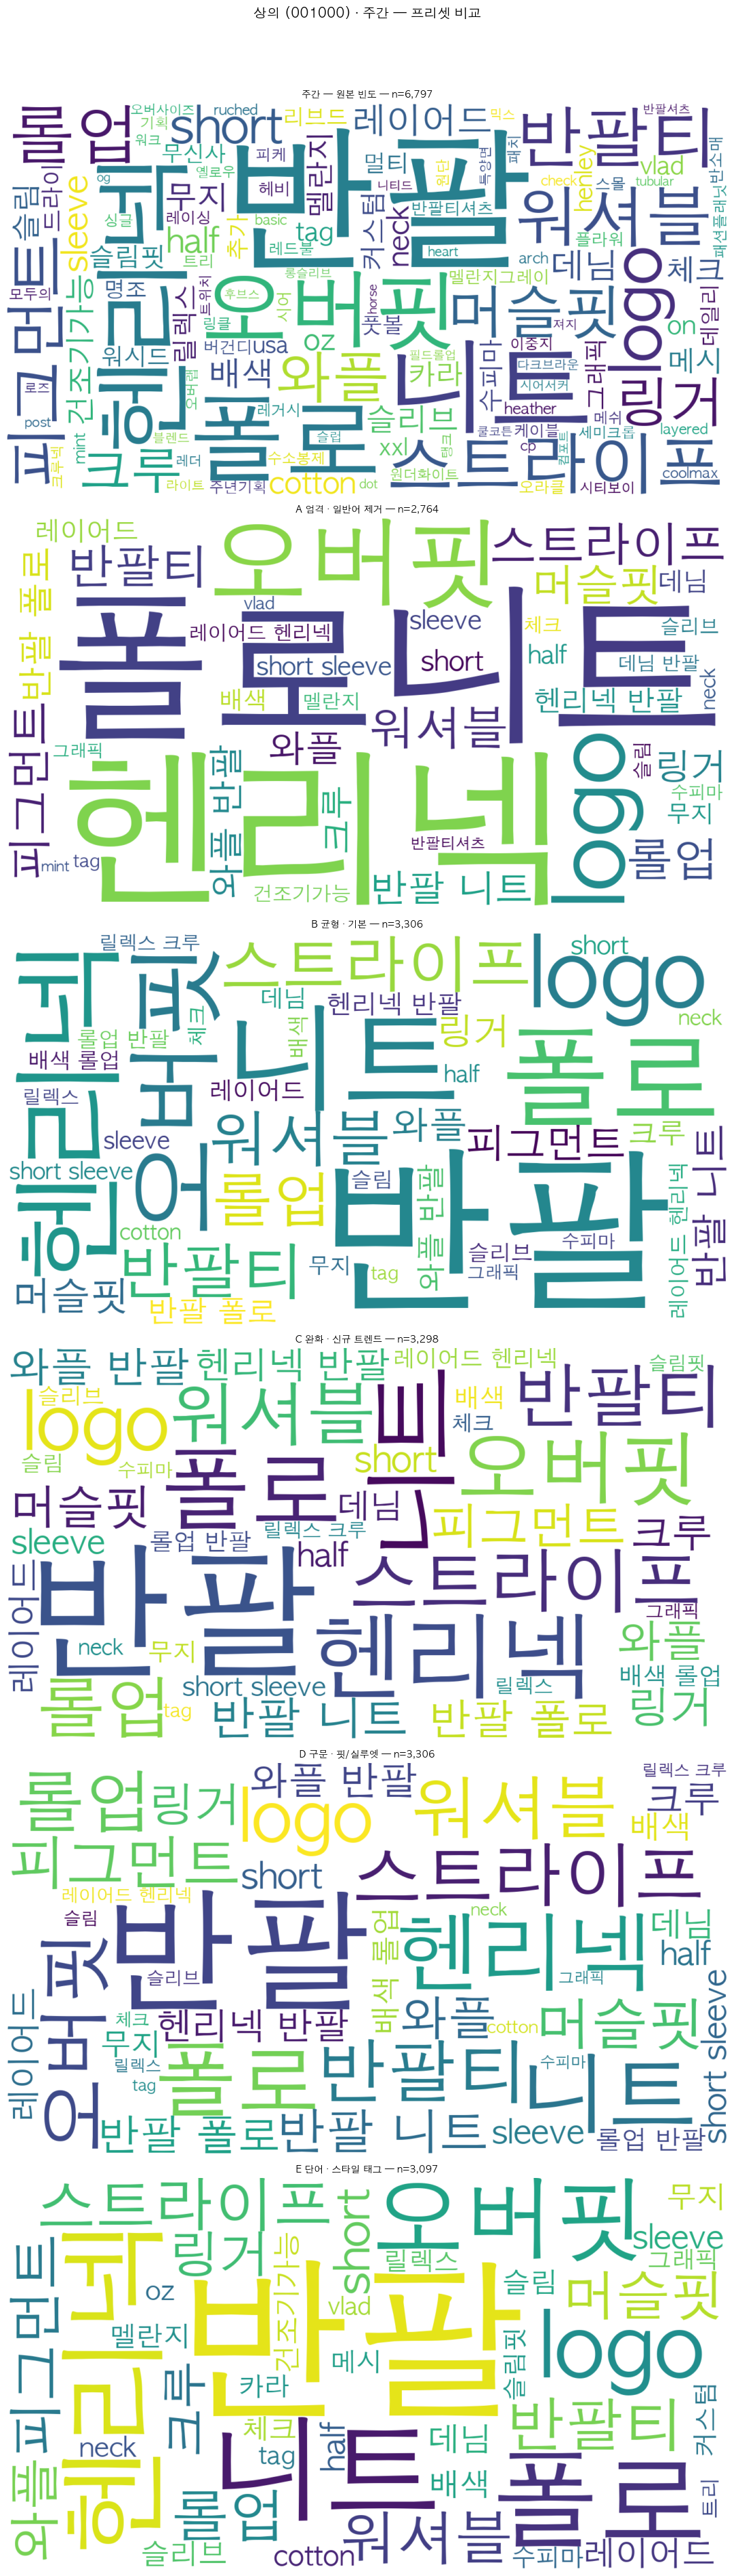

In [25]:
wlabel = WINDOW_LABEL_KR.get(TARGET_WINDOW_ID, TARGET_WINDOW_ID)
wc_panels: list[tuple[str, Counter]] = [(f"{wlabel} — 원본 빈도", raw_ctr)]
for preset in PARAM_PRESETS:
    pid = preset["preset_id"]
    wc_panels.append((preset["label"], preset_counters[pid]))

wl.plot_wordcloud_column(
    wc_panels,
    suptitle=f"{TARGET_CATEGORY_LABEL} ({TARGET_CATEGORY_CODE}) · {wlabel} — 프리셋 비교",
    figsize_per_cell=(14.0, 6.2),
    wordcloud_width=1400,
    wordcloud_height=760,
    save_path=OUTPUT_DIR / f"{run_dir.name}_{TARGET_CATEGORY_CODE}_{TARGET_WINDOW_ID}_preset_compare_wordcloud.png",
)


In [26]:
# 프리셋별 일반어/고문서빈도 잔존 점검
leak_rows = []
for preset in PARAM_PRESETS:
    pid = preset["preset_id"]
    sub = preset_tables[pid]
    leaked = sub[(sub["term"].isin(GENERIC_CHECK)) | (sub["doc_freq_ratio"] >= HIGH_DF_THRESHOLD)]
    leak_rows.append(
        {
            "preset_id": pid,
            "preset_label": preset["label"],
            "leak_count": len(leaked),
            "leak_terms": ", ".join(leaked["term"].head(8).tolist()),
        }
    )
leak_df = pd.DataFrame(leak_rows)
display(leak_df)


,preset_id,preset_label,leak_count,leak_terms
0,A_strict,A 엄격 · 일반어 제거,0,
1,B_balanced,B 균형 · 기본,1,반팔
2,C_loose_trend,C 완화 · 신규 트렌드,1,반팔
3,D_phrase_fit,D 구문 · 핏/실루엣,1,반팔
4,E_unigram_tag,E 단어 · 스타일 태그,1,반팔


In [27]:
tag = f"{run_dir.name}_{TARGET_CATEGORY_CODE}_{TARGET_WINDOW_ID}_preset_compare"
preset_compare_df.to_csv(OUTPUT_DIR / f"{tag}.csv", index=False, encoding="utf-8-sig")
wide_compare_df.to_csv(OUTPUT_DIR / f"{tag}_wide_top{COMPARE_RANK}.csv", index=False, encoding="utf-8-sig")
preset_meta_df.to_csv(OUTPUT_DIR / f"{tag}_meta.csv", index=False, encoding="utf-8-sig")
print("saved preset compare csv:", OUTPUT_DIR / f"{tag}.csv")


saved preset compare csv: /Users/bhc/dev/datadrift/v1/datadrift_app_engine/v2/silhouette_outliner/notebooks/output/product_name_single_window_tfidf_param_test/20260527_172433_001000_1w_preset_compare.csv


## 단일 설정 (수동)

설정 셀의 `MAX_DF_RATIO` 등을 바꿔 1회만 검증할 때 사용합니다.


In [28]:
top_terms_with_freq = run_tfidf_scope(
    scope_docs_df,
    top_k=TOP_K,
    ngram_range=NGRAM_RANGE,
    min_df_ratio=MIN_DF_RATIO,
    max_df_ratio=MAX_DF_RATIO,
    use_sublinear_tf=USE_SUBLINEAR_TF,
)
filtered_ctr = counter_from_top_terms(top_terms_with_freq)
display(top_terms_with_freq[["rank", "term", "count", "doc_freq_ratio", "tfidf"]])


,rank,term,count,doc_freq_ratio,tfidf
0,1,반팔,538,0.263855,139.077914
1,2,logo,106,0.051986,75.472844
2,3,니트,174,0.085336,54.550068
3,4,폴로,149,0.073075,53.819323
4,5,헨리넥,165,0.080922,51.677804
5,6,스트라이프,106,0.051986,50.966051
6,7,피그먼트,94,0.045120,46.709525
7,8,반팔티,104,0.051005,42.713481
8,9,오버핏,117,0.057381,41.005079
9,10,롤업,100,0.049044,38.326017


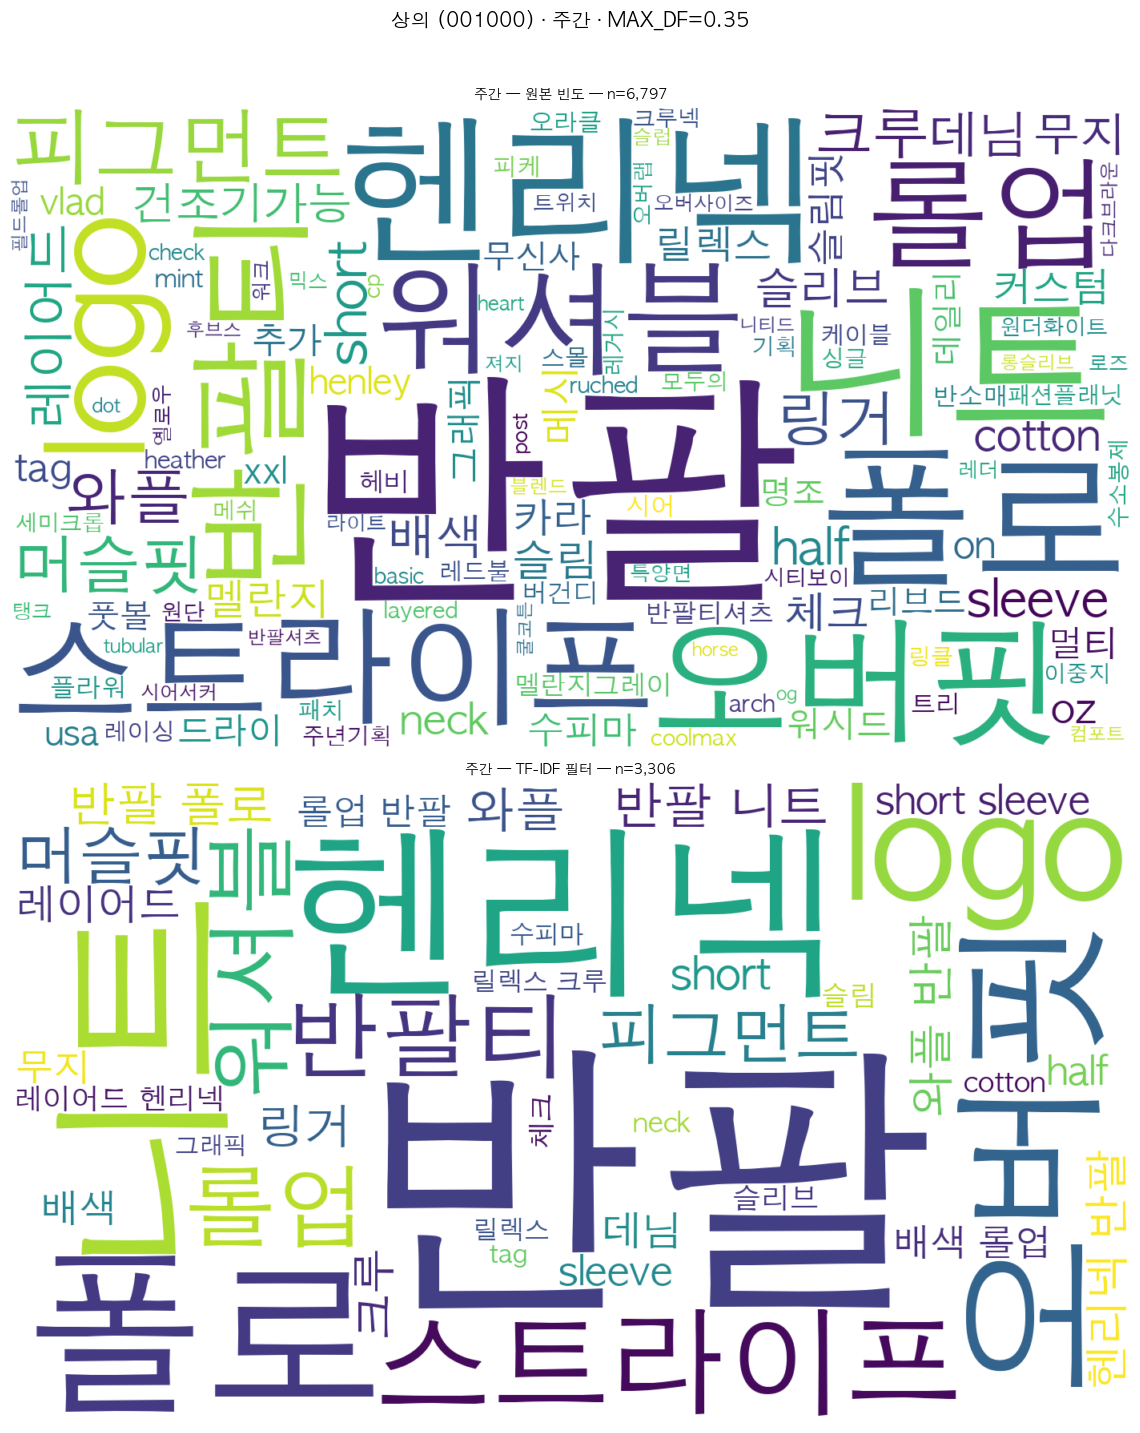

In [29]:
wlabel = WINDOW_LABEL_KR.get(TARGET_WINDOW_ID, TARGET_WINDOW_ID)
suptitle = f"{TARGET_CATEGORY_LABEL} ({TARGET_CATEGORY_CODE}) · {wlabel} · MAX_DF={MAX_DF_RATIO}"

wl.plot_wordcloud_column(
    [
        (f"{wlabel} — 원본 빈도", raw_ctr),
        (f"{wlabel} — TF-IDF 필터", filtered_ctr),
    ],
    suptitle=suptitle,
    figsize_per_cell=(14.0, 7.0),
    wordcloud_width=1400,
    wordcloud_height=800,
    save_path=OUTPUT_DIR / f"{run_dir.name}_{TARGET_CATEGORY_CODE}_{TARGET_WINDOW_ID}_maxdf{MAX_DF_RATIO}_wordcloud.png",
)


In [30]:
check = top_terms_with_freq[
    (top_terms_with_freq["term"].isin(GENERIC_CHECK))
    | (top_terms_with_freq["doc_freq_ratio"] >= HIGH_DF_THRESHOLD)
][["rank", "term", "count", "doc_freq_ratio", "tfidf"]]

if check.empty:
    print("점검: 일반어/고문서빈도 단어가 상위 TF-IDF에 없음")
else:
    print("점검 필요:")
    display(check)


점검 필요:


,rank,term,count,doc_freq_ratio,tfidf
0,1,반팔,538,0.263855,139.077914


In [31]:
if SAVE_CSV:
    tag = f"{run_dir.name}_{TARGET_CATEGORY_CODE}_{TARGET_WINDOW_ID}_maxdf{MAX_DF_RATIO}"
    out = OUTPUT_DIR / f"{tag}_top_terms_with_freq.csv"
    top_terms_with_freq.to_csv(out, index=False, encoding="utf-8-sig")
    print("saved:", out)


saved: /Users/bhc/dev/datadrift/v1/datadrift_app_engine/v2/silhouette_outliner/notebooks/output/product_name_single_window_tfidf_param_test/20260527_172433_001000_1w_maxdf0.35_top_terms_with_freq.csv
